In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [18]:
df = pd.read_csv("data/processed_esg_financial_data.csv")

print(df.shape)
df.head()

(11000, 16)


,company_id,company_name,industry,region,year,revenue,profit_margin,market_cap,growth_rate,esg_overall,esg_environmental,esg_social,esg_governance,carbon_emissions,water_usage,energy_consumption
0,1,Company_1,Retail,Latin America,2015,0.002342,0.371429,0.000388,0.552703,0.548108,0.607,0.335,0.768,0.000193,0.000321,0.000038
1,1,Company_1,Retail,Latin America,2016,0.002422,0.351429,0.000422,0.529730,0.544865,0.589,0.328,0.785,0.000203,0.000338,0.000040
2,1,Company_1,Retail,Latin America,2017,0.002926,0.360000,0.000360,0.745946,0.542703,0.576,0.340,0.778,0.000247,0.000411,0.000049
3,1,Company_1,Retail,Latin America,2018,0.002890,0.347143,0.000325,0.471622,0.558919,0.623,0.334,0.783,0.000233,0.000389,0.000046
4,1,Company_1,Retail,Latin America,2019,0.002869,0.355714,0.000620,0.477027,0.543784,0.637,0.300,0.761,0.000228,0.000381,0.000045


In [19]:
target = 'growth_rate'

In [20]:
features = [
    'esg_environmental',
    'esg_social',
    'esg_governance',
    'carbon_emissions',
    'water_usage',
    'energy_consumption'
]

In [21]:
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [25]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [26]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name} Performance:")
    print("R2:", round(r2_score(y_true, y_pred), 3))
    print("MAE:", round(mean_absolute_error(y_true, y_pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 3))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression Performance:
R2: 0.048
MAE: 0.09
RMSE: 0.118

Random Forest Performance:
R2: 0.12
MAE: 0.088
RMSE: 0.113


In [27]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=5
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

evaluate(y_test, y_pred_best, "Tuned Random Forest")


Tuned Random Forest Performance:
R2: 0.143
MAE: 0.087
RMSE: 0.112


In [30]:
cv_scores = cross_val_score(best_model, X, y, cv=5)

print("CV Mean Score:", round(cv_scores.mean(), 3))

CV Mean Score: 0.033


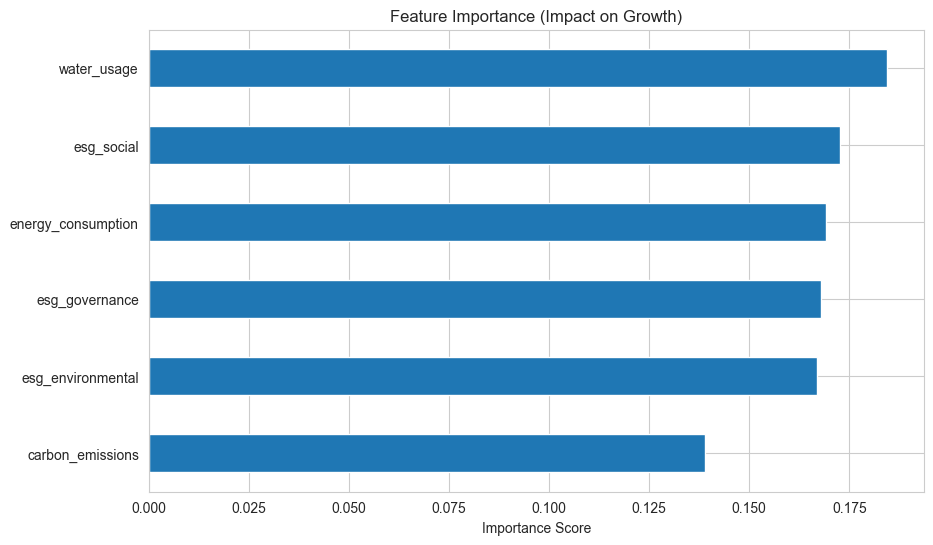

In [31]:
importances = best_model.feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values()

feat_imp.plot(kind='barh')
plt.title("Feature Importance (Impact on Growth)")
plt.xlabel("Importance Score")
plt.show()

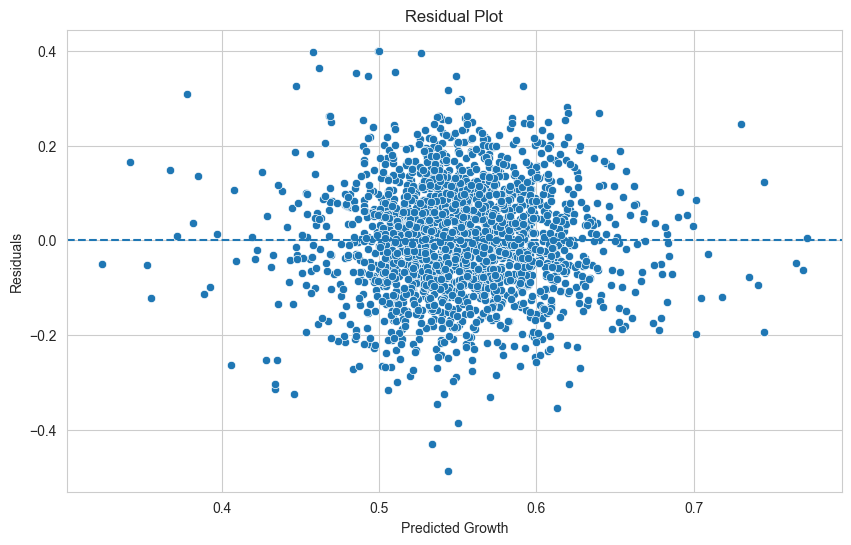

In [32]:
residuals = y_test - y_pred_best

sns.scatterplot(x=y_pred_best, y=residuals)
plt.axhline(0, linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Growth")
plt.ylabel("Residuals")
plt.show()

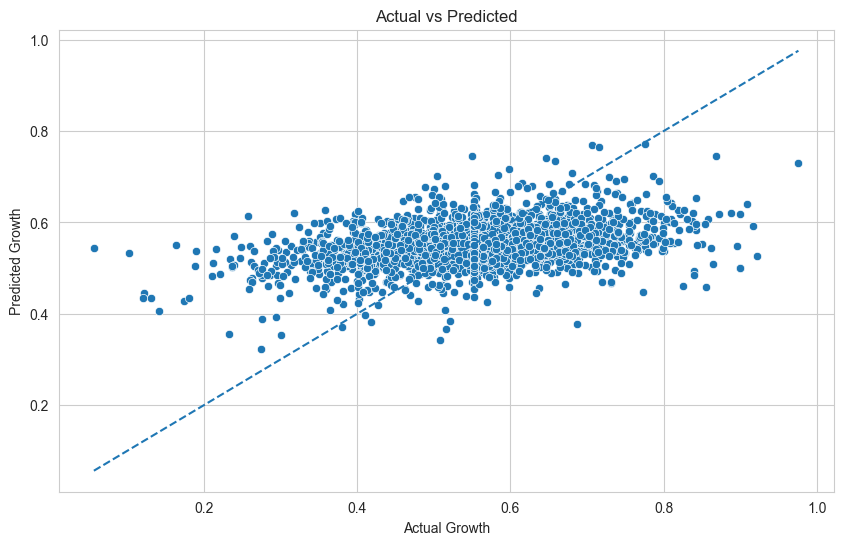

In [33]:
sns.scatterplot(x=y_test, y=y_pred_best)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--')

plt.title("Actual vs Predicted")
plt.xlabel("Actual Growth")
plt.ylabel("Predicted Growth")
plt.show()

In [38]:
import joblib


joblib.dump({
    "model": best_model,                     # final trained model
    "scaler": scaler,                        # required for transforming new data
    "features": X.columns.tolist()           # exact feature order
}, "model.pkl")

print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [39]:
grid.fit(X_train, y_train)
best_model = grid.best_estimator_